# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

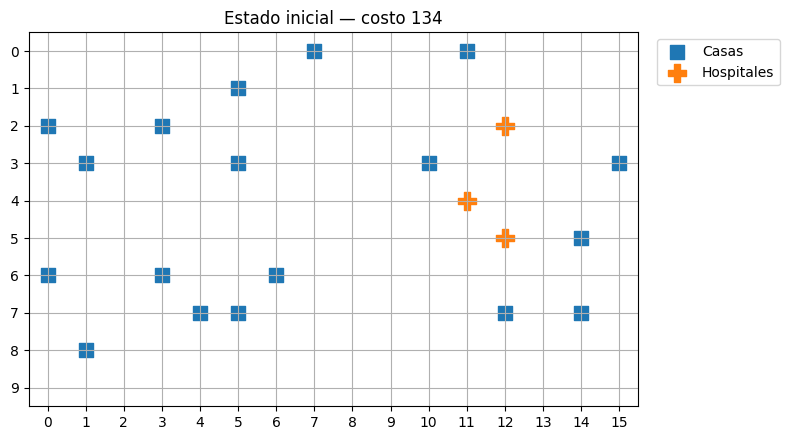

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [4]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


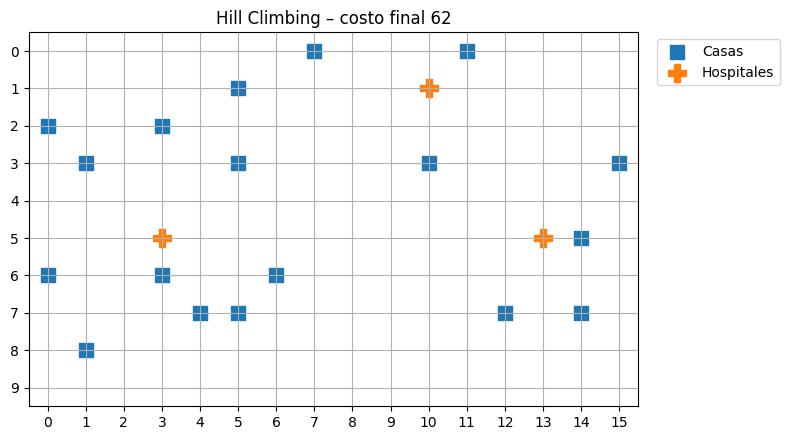

In [5]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None,
                  cost_fn=total_cost, neighbor_fn=neighbors_of_state):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [cost_fn(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbor_fn(height, width, houses, current)
        if not neighbors:
            break

        costs = [cost_fn(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing – costo final {history[-1]}')

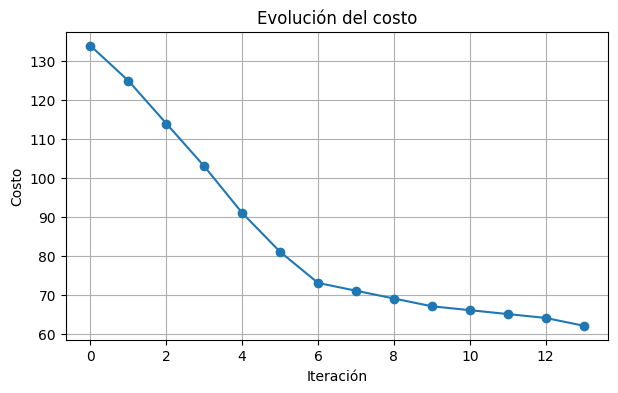

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


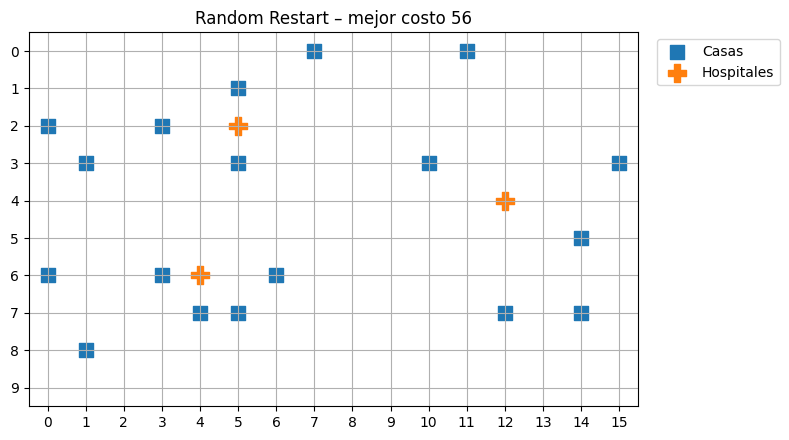

In [7]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0,
                    cost_fn=total_cost, neighbor_fn=neighbors_of_state):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed),
            cost_fn=cost_fn, neighbor_fn=neighbor_fn
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart – mejor costo {best["final_cost"]}')

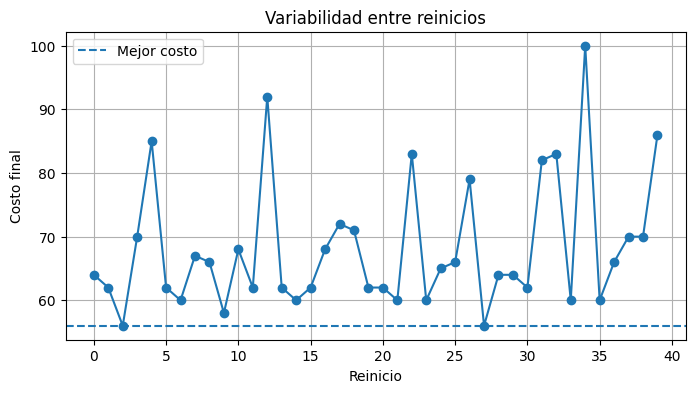

In [8]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

Costo inicial (euclidea): 111.2
Costo final (euclidea): 46.7
Costo final (Manhattan, referencia): 62
Mismos hospitales que con Manhattan: False


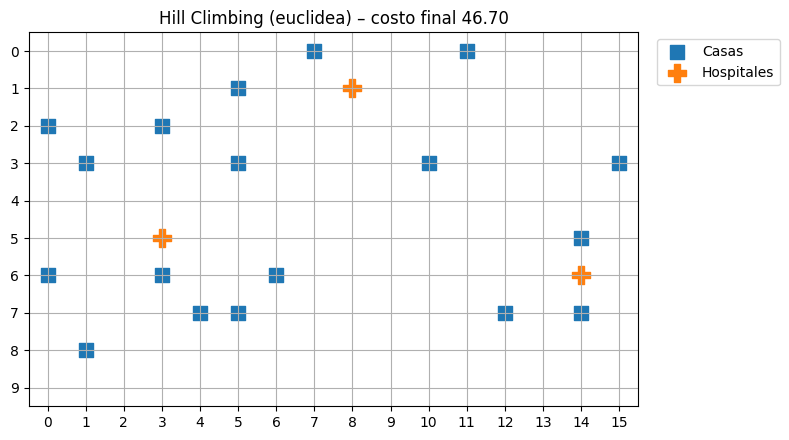

In [9]:
import math


def euclidean(a, b):
    return math.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
               for house in houses)


solution_eucl, history_eucl, _ = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED),
    cost_fn=total_cost_euclidean
)

print('Costo inicial (euclidea):', round(history_eucl[0], 2))
print('Costo final (euclidea):', round(history_eucl[-1], 2))
print('Costo final (Manhattan, referencia):', history[-1])
print('Mismos hospitales que con Manhattan:', solution_eucl == solution)

plot_state(HEIGHT, WIDTH, houses, solution_eucl,
           title=f'Hill Climbing (euclidea) – costo final {history_eucl[-1]:.2f}')

**Discusion – Actividad 1**

Con distancia Manhattan el costo final fue **62** y con distancia euclidea **46.7**, y la ubicacion final de los hospitales **cambio** (`solution_eucl == solution` da `False`).

Los dos numeros no son directamente comparables en magnitud: para cualquier par de puntos, `euclidea(a,b) <= manhattan(a,b)` (la euclidea es la hipotenusa, la Manhattan es la suma de catetos), asi que el costo euclideo *siempre* va a verse mas bajo aunque la solucion no sea "mejor" en un sentido absoluto. Lo relevante no es el numero crudo, sino que **el optimo local encontrado depende de la metrica**: al cambiar la forma de medir distancia cambia la forma de las "cuencas" de atraccion alrededor de cada hospital, por lo que Hill Climbing converge a una configuracion distinta aunque el vecindario (los movimientos posibles) sea el mismo.

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [10]:
results = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=40, seed=SEED)
    results.append((k, best_k['final_cost']))

results

[(1, 114), (2, 76), (3, 56), (4, 46), (5, 38)]

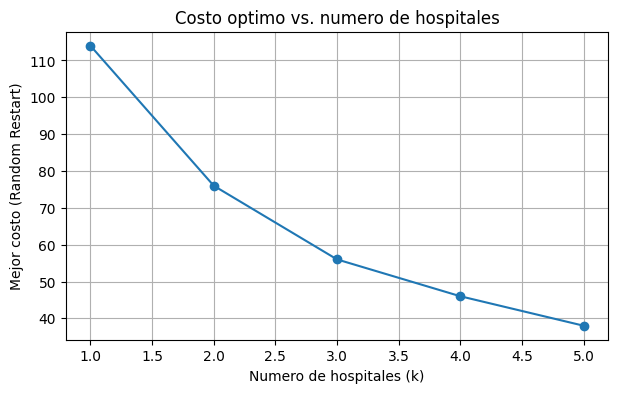

In [11]:
ks = [k for k, _ in results]
costs_k = [c for _, c in results]

plt.figure(figsize=(7, 4))
plt.plot(ks, costs_k, marker='o')
plt.xlabel('Numero de hospitales (k)')
plt.ylabel('Mejor costo (Random Restart)')
plt.title('Costo optimo vs. numero de hospitales')
plt.grid(True)
plt.show()

**Discusion – Actividad 2**

Resultados obtenidos (Random Restart, 40 reinicios, misma semilla):

| k (hospitales) | Mejor costo | Reduccion vs. k-1 |
|---|---|---|
| 1 | 114 | — |
| 2 | 76  | -38 |
| 3 | 56  | -20 |
| 4 | 46  | -10 |
| 5 | 38  | -8  |

Agregar hospitales **no** produce siempre la misma reduccion: los primeros hospitales adicionales generan caidas grandes (de 1 a 2 hospitales el costo casi se divide a la mitad), pero la mejora marginal decrece con cada hospital nuevo (de 4 a 5 solo baja 8). Es el patron tipico de **retornos decrecientes**: con pocos hospitales, cada uno cubre una zona grande sin competencia; a medida que hay mas hospitales, las zonas que cada uno "gana" se solapan y son cada vez mas pequenas, asi que el beneficio marginal de anadir uno mas se reduce.

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

Vecinos evaluados (vecindario original, 1 celda): 12
Vecinos evaluados (vecindario extendido, hasta 2 celdas): 22
Costo final (vecindario original): 62
Costo final (vecindario extendido): 62


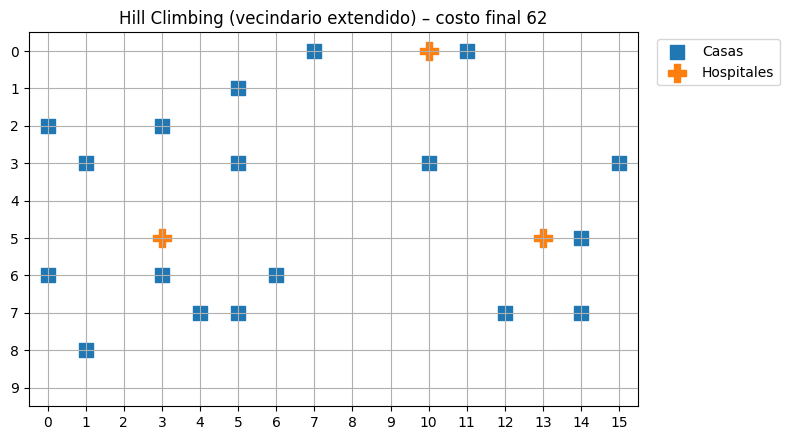

In [12]:
def neighbors_of_state_extended(height, width, houses, hospitals, max_step=2):
    neighbors = []
    moves = []
    for step in range(1, max_step + 1):
        moves += [(-step, 0), (step, 0), (0, -step), (0, step)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


neighbors_orig = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
neighbors_ext = neighbors_of_state_extended(HEIGHT, WIDTH, houses, initial_hospitals)
print('Vecinos evaluados (vecindario original, 1 celda):', len(neighbors_orig))
print('Vecinos evaluados (vecindario extendido, hasta 2 celdas):', len(neighbors_ext))

solution_ext, history_ext, _ = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED),
    neighbor_fn=neighbors_of_state_extended
)

print('Costo final (vecindario original):', history[-1])
print('Costo final (vecindario extendido):', history_ext[-1])

plot_state(HEIGHT, WIDTH, houses, solution_ext,
           title=f'Hill Climbing (vecindario extendido) – costo final {history_ext[-1]}')

**Discusion – Actividad 3**

Con el vecindario original (movimientos de 1 celda) se evaluaron **12** vecinos en el primer paso desde el estado inicial; con el vecindario extendido (movimientos de 1 o 2 celdas en cada direccion cardinal) se evaluaron **22** vecinos, es decir, casi el doble de trabajo por iteracion (el maximo teorico serian `3 hospitales x 8 movimientos = 24`, pero algunas celdas quedan fuera de la grilla u ocupadas y se filtran).

A pesar de evaluar casi el doble de vecinos por paso, el costo final **no mejoro** en esta corrida (62 en ambos casos): Hill Climbing sigue siendo una busqueda voraz que se detiene apenas ningun vecino mejora el costo actual, y un vecindario mas grande no cambia esa regla de parada, solo cambia *cuales* vecinos estan disponibles en cada paso. Un vecindario mas grande puede ayudar a saltar mesetas pequenas o rodear ciertos optimos locales, pero tambien puede llevar por un camino distinto que termine en un optimo local diferente (mejor, igual o peor) — no hay garantia de mejora, solo mas costo computacional por iteracion.

## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?
2. ¿El resultado depende del estado inicial?
3. ¿Random Restart garantiza encontrar el óptimo global?
4. ¿Qué información se pierde al conservar únicamente el mejor vecino?

**Respuestas**

1. **¿Por que Hill Climbing no necesita construir todo el espacio de busqueda?**
   Porque en cada paso solo genera y evalua los vecinos del estado *actual* (aqui, mover un hospital a una celda adyacente), no todas las combinaciones posibles de posiciones de hospitales. El espacio completo crece exponencialmente con el numero de hospitales y celdas, pero Hill Climbing solo necesita comparar un puñado de vecinos por iteracion para decidir a donde moverse.

2. **¿El resultado depende del estado inicial?**
   Si. La corrida guiada partiendo de `initial_hospitals` termino en costo 62, mientras que Random Restart (que prueba muchos estados iniciales distintos) encontro un costo de 56 con otro punto de partida (y en la Actividad 1, cambiar solo la metrica de distancia ya cambio la solucion final). Como Hill Climbing es voraz y se detiene en el primer optimo local, distintos puntos de partida pueden quedar atrapados en distintos optimos locales.

3. **¿Random Restart garantiza encontrar el optimo global?**
   No. Random Restart solo aumenta la probabilidad de encontrar el optimo global (o algo muy cercano) al probar mas puntos de partida, pero sigue sin tener ninguna garantia formal: si ningun reinicio cae en la cuenca de atraccion del optimo global, el mejor resultado reportado seguira siendo un optimo local. En la Actividad 2, por ejemplo, no hay forma de saber, solo con estos experimentos, si 38 (con k=5) es realmente el minimo global posible.

4. **¿Que informacion se pierde al conservar unicamente el mejor vecino?**
   Se pierde toda la estructura del vecindario: que tan buenos eran los demas vecinos, si habia varios vecinos empatados o casi empatados (lo que sugeriria una meseta), y la direccion general de mejora. Al quedarse solo con el mejor vecino, el algoritmo no puede "recordar" alternativas cercanas si mas adelante se topa con un optimo local, por lo que no puede retroceder ni explorar otras ramas sin reiniciar el proceso.